In [1]:
# enc dec =1, 1
# Pennylane implementation of your VQ Ramsey interferometer training (Adam optimizer)
import os
import numpy as np
from numpy.polynomial.hermite import hermgauss
import pennylane as qml
import pennylane.numpy as pnp
from itertools import combinations
from collections import defaultdict
import copy
import matplotlib.pyplot as plt
import time

# ========== Step 1. 基础参数 ==========
n_qubits = 8
maxiter = 3000
phi_train_samples = 100
test_phi_num = 50
N_REPEAT = 10
dphi = 1e-5
scope = [-np.pi, np.pi]
phi_std = 0.7  # 论文中的 δφ
n_enc, n_dec = 1, 1

path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}"
os.makedirs(path, exist_ok=True)

# ========== helper: hermite-gauss quadrature ==========
def w_phi(sigma_phi, n):
    xs, ws = hermgauss(n)
    phis = np.sqrt(2) * sigma_phi * xs
    weights = ws / np.sqrt(np.pi)
    return weights, phis

weights, phi_train = w_phi(phi_std, phi_train_samples)  # same as original
phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, np.pi + np.pi/phi_train_samples, 50)

# ---------------- utility: mapping between index and m value --------------
# Precompute mapping from basis index -> m (number of 0 minus number of 1)
dim = 2**n_qubits
index_to_m = np.zeros(dim, dtype=int)
for idx in range(dim):
    bitstr = format(idx, f"0{n_qubits}b")
    m = bitstr.count('0') - bitstr.count('1')
    index_to_m[idx] = m
unique_m = np.unique(index_to_m)

# ----------------- PennyLane device & QNode -----------------
dev = qml.device("default.qubit", wires=n_qubits)

# convenience rzz implementation to match earlier qiskit-like pattern
def rzz_qiskit(chi, i, j):
    qml.CNOT(wires=[i, j])
    qml.RZ(chi, wires=j)
    qml.CNOT(wires=[i, j])

# QNode: outputs probabilities over computational basis for given phi and flat parameter vector x
# x is a 1D pnp.array containing [3*n_enc thetas, 3*n_dec curly_thetas, a]
@qml.qnode(dev, interface="autograd")
def circuit_probs(phi, x):
    # unpack x within the QNode (works with autograd/pennylane)
    # Extract theta and curly theta
    theta_flat = x[: 3 * n_enc] if n_enc > 0 else pnp.array([])
    curly_flat = x[3 * n_enc : 3 * n_enc + 3 * n_dec] if n_dec > 0 else pnp.array([])
    # 'a' is not used inside the quantum circuit, only in classical loss
    # Build circuit following build_U_R
    # input rotation Ry(pi/2) on all qubits
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # --- build U_en (encoding) ---
    # theta_flat is grouped in triples
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        # layer_en: twisting_z(t1) -> twisting_x(t2) -> collective_rx(t3)
        # twisting_z: apply IsingZZ pairwise
        for i, j in combinations(range(n_qubits), 2):
            # qml.IsingZZ(gamma, wires=[i,j]) implements exp(-i gamma/2 Z⊗Z) (PennyLane convention)
            # qml.IsingZZ(t1 / 2.0, wires=[i, j])  # scale to mimic rzz(chi/2) behavior
            rzz_qiskit(t1 / 2.0, i, j)
        # twisting_x: H, twisting_z(t2), H
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            # qml.IsingZZ(t2 / 2.0, wires=[i, j])
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        # collective_rx
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # --- phase encoding Rz(phi) collective ---
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # --- build U_de (decoding) ---
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        # layer_de: collective_rx(v3) -> twisting_x(v2) -> twisting_z(v1)
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        # twisting_x(v2)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            # qml.IsingZZ(v2 / 2.0, wires=[i, j])
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        # twisting_z(v1)
        for i, j in combinations(range(n_qubits), 2):
            # qml.IsingZZ(v1 / 2.0, wires=[i, j])
            rzz_qiskit(v1 / 2.0, i, j)

    # final rotation Rx(pi/2)
    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    # Return probabilities over computational basis
    return qml.probs(wires=list(range(n_qubits)))

# ---------------------------
# 2. QNode 定义 (返回纯态)
# ---------------------------
# dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="autograd")
def circuit_state(phi, x):
    """构建和训练一致的 U_R 电路，返回最终态向量"""
    theta_flat = x[:3*n_enc] if n_enc>0 else pnp.array([])
    curly_flat = x[3*n_enc:3*n_enc+3*n_dec] if n_dec>0 else pnp.array([])
    a = x[-1]  # 训练参数 a, 不影响量子电路

    # --- 输入态旋转 Ry(pi/2)
    for q in range(n_qubits):
        qml.RY(pnp.pi/2, wires=q)

    # --- 编码层 U_en
    for layer_idx in range(n_enc):
        t1, t2, t3 = theta_flat[layer_idx*3:layer_idx*3+3]
        for i,j in combinations(range(n_qubits),2):
            # qml.IsingZZ(t1 / 2.0, wires=[i, j])
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            # qml.IsingZZ(t2 / 2.0, wires=[i, j])
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # --- 相位编码
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # --- 解码层 U_de
    for layer_idx in range(n_dec):
        v1, v2, v3 = curly_flat[layer_idx*3:layer_idx*3+3]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            # qml.IsingZZ(v2/2, wires=[i,j])
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            # qml.IsingZZ(v1/2, wires=[i,j])
            rzz_qiskit(v1 / 2.0, i, j)
    
    # --- 最终旋转
    for q in range(n_qubits):
        qml.RX(pnp.pi/2, wires=q)

    return qml.state()

# ---------------- parameter helpers (same layout as original) ----------------
def params_init(n_enc, n_dec, use_a=True):
    if n_enc + n_dec == 0:
        return pnp.array([])
    theta_init = np.random.uniform(-0.1, 0.1, 3*n_enc)
    curly_theta_init = np.random.uniform(-0.1, 0.1, 3*n_dec)
    if use_a:
        a_init = np.array([1.0 + np.random.uniform(-0.1, 0.1)])
        x0 = np.concatenate([theta_init, curly_theta_init, a_init])
    else:
        x0 = np.concatenate([theta_init, curly_theta_init])
    return pnp.array(x0, requires_grad=True)

def parse_params(x, n_enc, n_dec, use_a=True):
    theta_params = [tuple(x[i*3:(i+1)*3]) for i in range(n_enc)]
    start_dec = 3 * n_enc
    curly_theta_params = [
        tuple(x[start_dec + i*3 : start_dec + (i+1)*3]) for i in range(n_dec)
    ]
    if use_a:
        a = x[-1]
        return theta_params, curly_theta_params, a
    else:
        return theta_params, curly_theta_params


@qml.qnode(dev, interface="autograd")
def generator_variance(x):
    # 构建 circuit 与 circuit_state 一样，但 phi=0
    # 输入态
    for q in range(n_qubits):
        qml.RY(pnp.pi/2, wires=q)

    # 编码层 U_en
    for layer_idx in range(n_enc):
        t1, t2, t3 = x[layer_idx*3:layer_idx*3+3]
        for i,j in combinations(range(n_qubits),2):
            rzz_qiskit(t1/2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            rzz_qiskit(t2/2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # 解码层 U_de
    start_dec = 3*n_enc
    for layer_idx in range(n_dec):
        v1, v2, v3 = x[start_dec + layer_idx*3: start_dec + (layer_idx+1)*3]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            rzz_qiskit(v2/2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i,j in combinations(range(n_qubits),2):
            rzz_qiskit(v1/2.0, i, j)

    # generator G
    G = sum(qml.PauliZ(i) for i in range(n_qubits)) / 2

    return qml.var(G)
    
# ---------------- compute bmse for a list of phi using probs from QNode ----------------
def compute_bmse_from_probs_vectorized(x, phi_list, weights):
    """
    phi_list: numpy array of shape (N,)
    weights: corresponding quadrature weights (same length)
    x: flat parameters pnp.array
    Returns: weighted BMSE values (array of length len(phi_list))
    """
    qfi =  generator_variance(x)
    bmse_list = []
    # call circuit_probs for each phi
    for phi in phi_list:
        probs = circuit_probs(phi, x)   # pnp array of length 2^n_qubits
        # compute bmse from probs and index_to_m
        # probs is ordered in computational basis index order
        # convert to float pnp
        probs = pnp.array(probs)
        # m values are index_to_m
        # bmse = pnp.sum((phi - x[-1] * index_to_m) ** 2 * probs)
        p_m = pnp.array([pnp.sum(probs[index_to_m == m]) for m in unique_m])
        # bmse = pnp.sum((phi - x[-1] * unique_m)**2 * p_m)
        bmse = pnp.sum((phi - unique_m)**2 * p_m)
        bmse_list.append(bmse)
    bmse_array = pnp.stack(bmse_list)
    return pnp.sum(bmse_array * weights) / qfi # elementwise multiply by quadrature weights

def compute_bmse_with_dynamic_a(x, phi_list, weights):
    # ① 当前量子参数下，解析求最优 a
    a_opt = fit_optimal_a(x, phi_list, weights)
    bmse_list = []
    for phi in phi_list:
        probs = circuit_probs(phi, x)
        probs = pnp.array(probs)

        p_m = pnp.array([pnp.sum(probs[index_to_m == m]) for m in unique_m])

        # estimator φ̂(m) = a_opt * m
        bmse = pnp.sum((phi - a_opt * unique_m)**2 * p_m)
        bmse_list.append(bmse)

    bmse_array = pnp.stack(bmse_list)
    return pnp.sum(bmse_array * weights), a_opt

def fit_optimal_a(x, phi_list, weights):
    num = pnp.array(0.0)
    den = pnp.array(0.0)

    for phi, w in zip(phi_list, weights):
        probs = circuit_probs(phi, x)   # pnp ArrayBox OK

        p_m = pnp.array([
            pnp.sum(probs[index_to_m == m]) for m in unique_m
        ])

        m_mean = pnp.sum(unique_m * p_m)
        m2_mean = pnp.sum((unique_m**2) * p_m)

        num = num + w * phi * m_mean
        den = den + w * m2_mean

    return num / den   # still pnp scalar (ArrayBox during training)

# ---------------- objective function (mean weighted BMSE) ----------------
def objective(x):
    bmse, _ = compute_bmse_with_dynamic_a(x, phi_train, weights)
    return bmse

# ---------------------------
# 3. QFI 计算函数
# ---------------------------
def compute_QFI(phi, x, dphi=dphi):
    """中心差分计算纯态下的 CFI 和 QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_q)

def evaluate_model(x, a_opt, phi_trues):
    """
    在测试集上计算
    1. test MSE
    2. average QFI
    """
    
    index_to_m_pnp = pnp.array(index_to_m)

    phi_preds = []
    mse_phi_list = []

    for phi in phi_trues:
        probs = circuit_probs(phi, x)

        phi_est_m = a_opt * index_to_m_pnp
        phi_pred = pnp.sum(phi_est_m * probs)

        mse_phi = pnp.sum((phi - phi_est_m)**2 * probs)

        phi_preds.append(float(phi_pred))
        mse_phi_list.append(float(mse_phi))

    phi_preds = np.array(phi_preds)
    mse_phi_list = np.array(mse_phi_list)

    mse_mean = np.mean((phi_preds - phi_trues)**2)

    # ----- QFI -----
    QFI = compute_QFI(0.0, x)

    return mse_mean, QFI
    
# -----------------------
# === Training ===
# -----------------------
x = params_init(n_enc, n_dec, use_a=False)  # pnp array with requires_grad=True
opt = qml.AdamOptimizer(stepsize=0.02)
mse_history = []
a_history = []
# ===== evaluation history =====
eval_epochs = []
eval_mse_list = []
eval_qfi_list = []

best_loss = np.inf
best_x = None
best_it = -1
patience = 100              # 连续50次不提升就停止
no_improve_count = 0
min_iters = 500
print("Starting training...")
t0 = time.time()

for it in range(1, maxiter + 1):
    x, loss_val = opt.step_and_cost(objective, x)
    # loss_val_f = float(loss_val)
    # mse_history.append(loss_val_f)

    # --- 用更新后的 x，重新计算 a ---
    loss_val_f, a_curr = compute_bmse_with_dynamic_a(x, phi_train, weights)

    mse_history.append(float(loss_val_f))
    a_history.append(float(a_curr))
    
    # ---- save best ----
    if loss_val_f < best_loss:
        best_loss = float(loss_val_f)
        best_x = pnp.array(x, requires_grad=True)
        best_a = float(a_curr)
        best_it = it
        no_improve_count = 0   # 有提升，清零
    else:
        no_improve_count += 1  # 没提升，计数+1

    if it % 5 == 0 or it <= 5:
        print(f"Iter {it:4d} | loss={loss_val_f:.6e} | best={best_loss:.6e} | a={best_a:.4f} | no_improve={no_improve_count}")

    # ===== 每10epoch评估一次 =====
    if it % 10 == 0:
        mse_test, qfi_test = evaluate_model(best_x, best_a, phi_trues)
        eval_epochs.append(it)
        eval_mse_list.append(mse_test)
        eval_qfi_list.append(qfi_test)
        print(f"   >>> Eval @ epoch {it}: Test MSE={mse_test:.4e}, QFI={qfi_test:.4f}")

    # ---- early stopping ----
    if it > min_iters and no_improve_count >= patience:
        print(f"\nEarly stopping at iter {it}, no improvement for {patience} iterations.")
        break

print(f"\nTraining finished in {time.time()-t0:.1f}s")
print(f"Best loss {best_loss:.6e} at iter {best_it}")

#尽管量子费舍尔信息量 (QFI) 在第 80 个周期左右达到最大值，但均方误差 (MSE) 会随着训练的进行而持续下降。这种现象的出现是因为训练目标是最小化估计误差，而不是直接最大化量子费舍尔信息量。QFI 量化了量子态对编码相位的固有敏感性，而最终的估计性能还取决于经典后处理网络从测量结果中提取信息的效率。在训练初期，提高量子态的相位敏感性有助于降低估计误差，从而导致 QFI 的快速增长。然而，在训练后期，神经网络逐渐学会利用测量分布的非线性结构，即使 QFI 略有下降，也能进一步降低 MSE。


Starting training...
Iter    1 | loss=1.201829e-01 | best=1.201829e-01 | a=0.1201 | no_improve=0
Iter    2 | loss=1.163976e-01 | best=1.163976e-01 | a=0.1210 | no_improve=0
Iter    3 | loss=1.128044e-01 | best=1.128044e-01 | a=0.1227 | no_improve=0
Iter    4 | loss=1.088242e-01 | best=1.088242e-01 | a=0.1248 | no_improve=0
Iter    5 | loss=1.041268e-01 | best=1.041268e-01 | a=0.1269 | no_improve=0
Iter   10 | loss=8.834587e-02 | best=8.834587e-02 | a=0.1351 | no_improve=0
   >>> Eval @ epoch 10: Test MSE=1.9118e+00, QFI=14.5672
Iter   15 | loss=8.896248e-02 | best=8.758731e-02 | a=0.1371 | no_improve=3
Iter   20 | loss=8.909204e-02 | best=8.758731e-02 | a=0.1371 | no_improve=8
   >>> Eval @ epoch 20: Test MSE=1.9115e+00, QFI=16.0784
Iter   25 | loss=8.629014e-02 | best=8.629014e-02 | a=0.1392 | no_improve=0
Iter   30 | loss=8.515282e-02 | best=8.515282e-02 | a=0.1381 | no_improve=0
   >>> Eval @ epoch 30: Test MSE=1.9075e+00, QFI=16.4367
Iter   35 | loss=8.486957e-02 | best=8.486957e-0

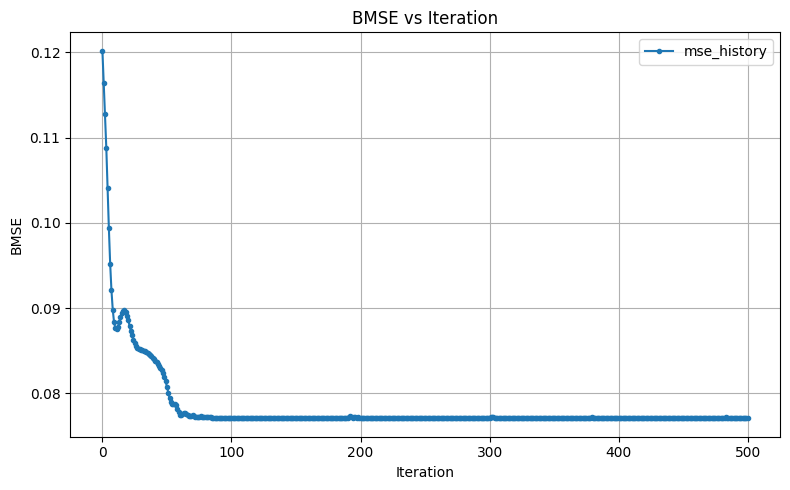

In [2]:

np.save(os.path.join(path, "mse_history.npy"), np.array(mse_history))
np.save(os.path.join(path, "eval_mse_list.npy"), np.array(eval_mse_list))
np.save(os.path.join(path, "eval_qfi_list.npy"), np.array(eval_qfi_list))

# ---------------- 绘图 ----------------
plt.figure(figsize=(8, 5))
plt.plot(mse_history, marker='.', label="mse_history")
plt.xlabel("Iteration")
plt.ylabel("BMSE")
plt.title("BMSE vs Iteration")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{path}/mse_history.png")
plt.show()


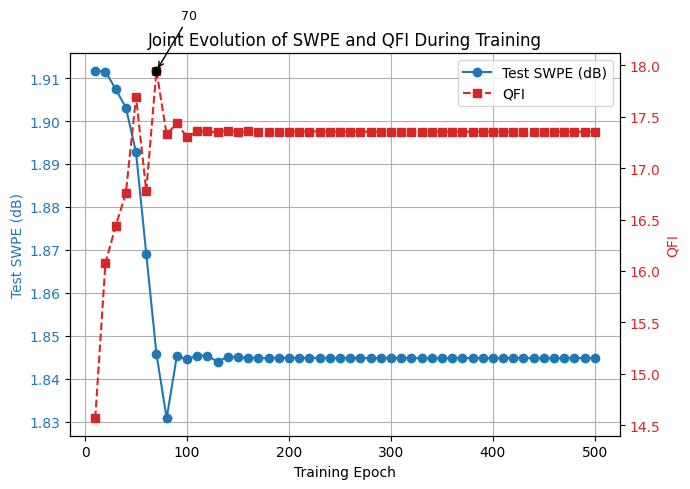

In [3]:
fig, ax1 = plt.subplots(figsize=(7,5))

# 左轴：SWPE（dB）
color1 = 'tab:blue'
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("Test SWPE (dB)", color=color1)
ax1.plot(eval_epochs, eval_mse_list, marker='o', color=color1, label="Test SWPE (dB)")
ax1.tick_params(axis='y', labelcolor=color1)

# 可选：让“越好越高”
# ax1.invert_yaxis()

# 右轴：QFI
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel("QFI", color=color2)
ax2.plot(eval_epochs, eval_qfi_list, marker='s', linestyle='--', color=color2, label="QFI")
ax2.tick_params(axis='y', labelcolor=color2)

# =========================
# ⭐ 找到首次最大QFI的位置
# =========================
qfi_array = np.array(eval_qfi_list)
epoch_array = np.array(eval_epochs)

qfi_array = np.array(eval_qfi_list)
epoch_array = np.array(eval_epochs)
mse_array = np.array(eval_mse_list)

max_qfi = np.max(qfi_array)
max_idx = np.where(qfi_array == max_qfi)[0][0]  # 第一次出现
max_epoch = epoch_array[max_idx]

# 对应点
x_point = max_epoch
y_point = max_qfi

# =========================
# ⭐ 标注（箭头 + 文本）
# =========================
ax2.scatter(x_point, y_point, color='black', zorder=5)

ax2.annotate(
    f"{max_epoch}",
    xy=(x_point, y_point),
    xytext=(x_point + (epoch_array[-1]-epoch_array[0])*0.05, y_point + 0.5),
    arrowprops=dict(arrowstyle="->", color='black'),
    fontsize=9
)

# =========================
# 图例合并
# =========================
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')

# 标题 + grid
plt.title("Joint Evolution of SWPE and QFI During Training")
ax1.grid(True)

fig.tight_layout()
plt.savefig(f"{path}/swpe_qfi_combined.png", dpi=300)
plt.show()


In [4]:
mse_array = np.array(eval_mse_list)

np.save(os.path.join(path, "qfi_array.npy"), np.array(qfi_array))
np.save(os.path.join(path, "epoch_array.npy"), np.array(epoch_array))
np.save(os.path.join(path, "mse_array.npy"), np.array(mse_array))

In [5]:
def compute_QFI(phi, x, dphi=1e-5):
    """中心差分计算纯态下的QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_q)

QFI = compute_QFI(0.0, best_x)
print(f"QFI: {QFI:.4f}")
np.save(os.path.join(path, "QFI.npy"), np.array([QFI]))


QFI: 17.3553


In [6]:
best_x

tensor([ 3.58809973e-01, -4.38641827e-02,  5.88536701e-01,
         5.08765401e-06,  1.68364862e-01,  9.57706065e-02], requires_grad=True)

<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_33572\1537073751.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_33572\1537073751.py:67: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")


Test MSE (phi_pred vs phi_true): 1.844837e+00


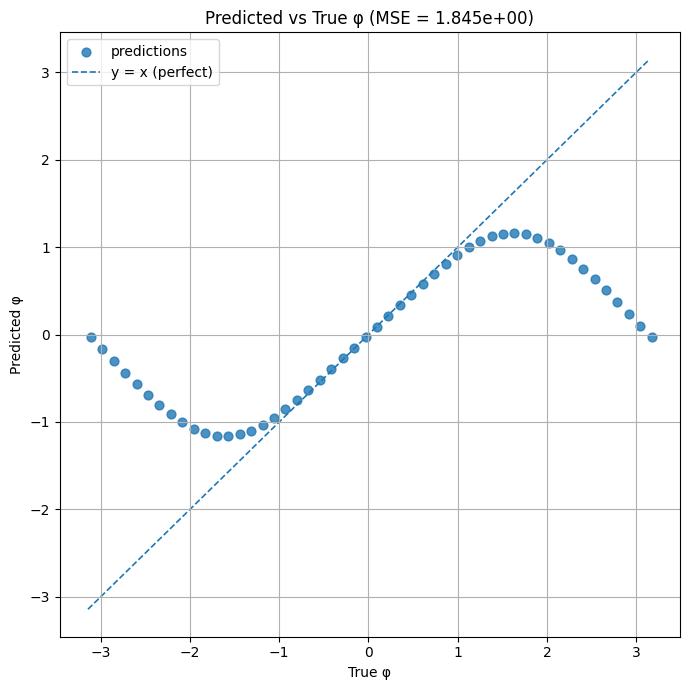

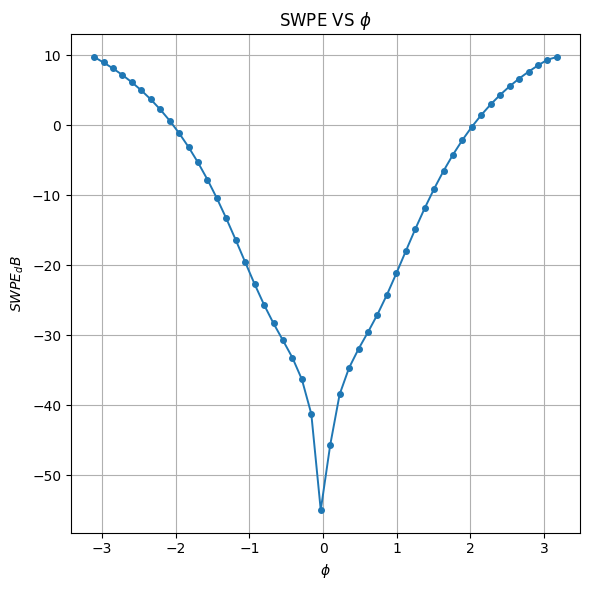

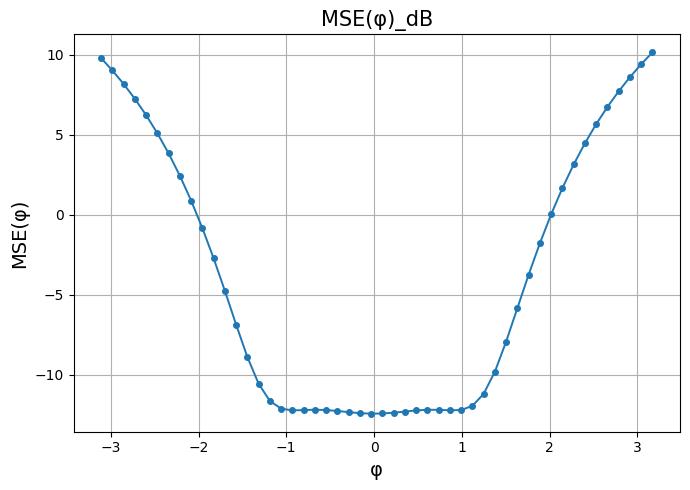

In [7]:
# ================== Prediction & Plot: phi_pred vs phi_true ==================
import matplotlib.pyplot as plt
import numpy as np

# 1) prepare test phi set (均匀分布在 scope 内)
# phi_trues = np.linspace(-np.pi + np.pi/phi_train_samples, np.pi + np.pi/phi_train_samples, 50)

# 2) compute predicted phi for each test phi: phi_pred = sum(a * m * p)
# ensure index_to_m is pnp-compatible array
index_to_m_pnp = pnp.array(index_to_m)

phi_preds = []
mse_phi_list = []
# Use the trained flat parameter vector x (pnp array)
# a_trained = best_x[-1]  # pnp scalar

for phi in phi_trues:
    probs = circuit_probs(phi, best_x)           # pnp array length 2^n_qubits
    # predicted phi = sum(a * m * p)
    # note: both a_trained and probs are pnp types so use pnp.sum for autograd compatibility
    # estimator φ_est(m) = a * m
    phi_est_m = best_a * index_to_m_pnp   # vector over all basis states
    phi_pred = pnp.sum(phi_est_m * probs)
    # MSE(phi) = sum_m (phi - phi_est(m))^2 * p(m|phi)
    mse_phi = pnp.sum((phi - phi_est_m)**2 * probs)

    phi_preds.append(float(phi_pred))       # convert to float for plotting
    mse_phi_list.append(float(mse_phi))

phi_preds = np.array(phi_preds)
mse_phi_list = np.array(mse_phi_list)
mse_phi_list_dB = 10*np.log10(mse_phi_list)

# 3) compute MSE between predicted and true (simple MSE)
mse_mean = np.mean((phi_preds - phi_trues)**2)
print(f"Test MSE (phi_pred vs phi_true): {mse_mean:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds.npy"), phi_preds)
np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# 4) plot phi_pred vs phi_true
plt.figure(figsize=(7,7))
plt.scatter(phi_trues, phi_preds, s=40, alpha=0.8, label="predictions")
# 45-degree reference line
lims = [min(scope[0], phi_preds.min()), max(scope[1], phi_preds.max())]
plt.plot(lims, lims, linestyle='--', linewidth=1.2, label="y = x (perfect)", zorder=-1)
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Predicted vs True φ (MSE = {mse_mean:.3e})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_dB$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE.png"), dpi=200)
plt.show()

# ----------- Plot MSE(phi) --------------
plt.figure(figsize=(7,5))
plt.plot(phi_trues, mse_phi_list_dB, marker="o", markersize=4, linewidth=1.4)
plt.xlabel("φ", fontsize=14)
plt.ylabel("MSE(φ)", fontsize=14)
plt.title("MSE(φ)_dB", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "mse_vs_phi.png"), dpi=200)
plt.show()


<>:111: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:111: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_33572\109462983.py:111: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel("$\phi$")
C:\Users\qingchuan.yang\AppData\Local\Temp\ipykernel_33572\109462983.py:113: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"SWPE VS $\phi$")
C:\Users\qingchuan.yang\AppData\Local\Programs\Python\Python313\Lib\site-packages\pennylane\devices\device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


Test MSE (phi_pred vs phi_true): 1.844853e+00


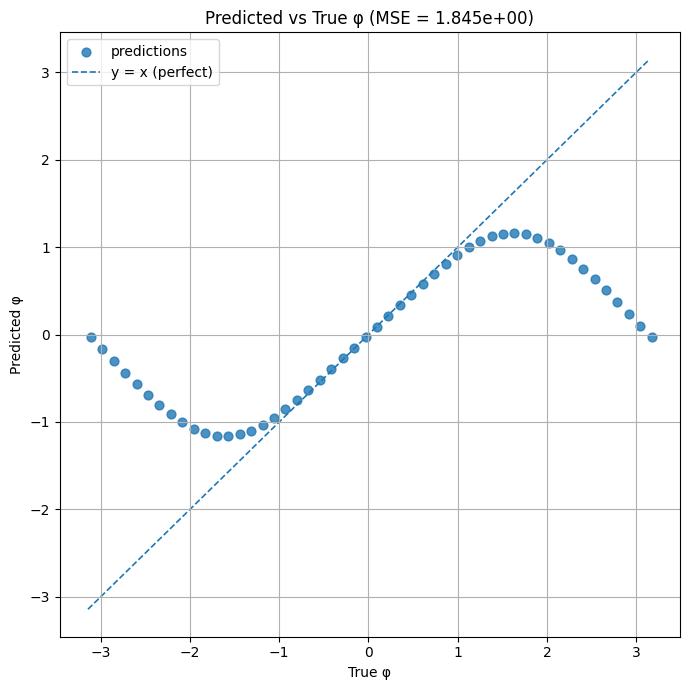

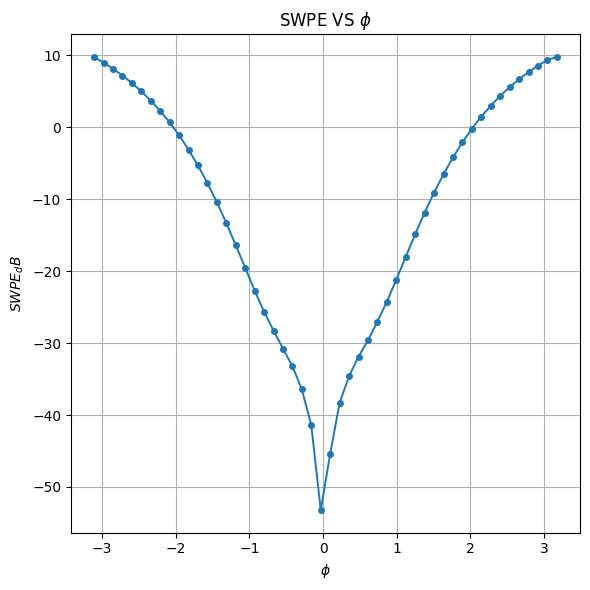

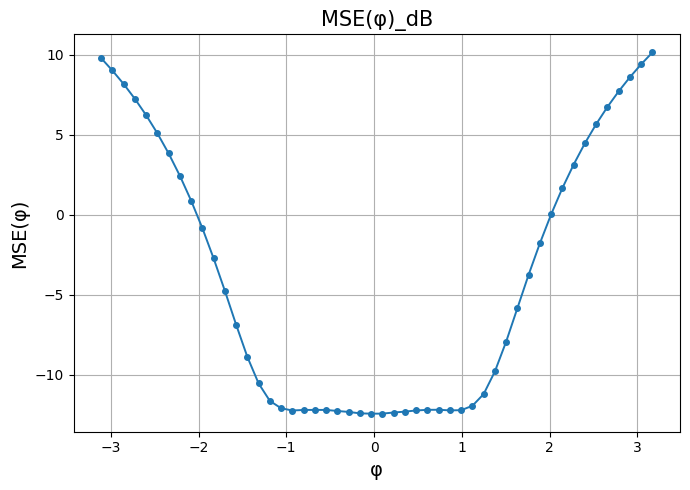

In [8]:
# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev_shots = qml.device("default.qubit", wires=n_qubits, shots=10**6)

@qml.qnode(dev_shots, interface=None)
def circuit_probs_shots(phi, q_params):
    """Return computational-basis probabilities for given phi and quantum parameters q_params."""
    # build same circuit but return probs
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=list(range(n_qubits)))

# 2) compute predicted phi for each test phi: phi_pred = sum(a * m * p)
# ensure index_to_m is pnp-compatible array
index_to_m_pnp = pnp.array(index_to_m)

phi_preds = []
mse_phi_list = []

for phi in phi_trues:
    probs = circuit_probs_shots(phi, best_x)           # pnp array length 2^n_qubits
    phi_est_m = best_a * index_to_m_pnp   # vector over all basis states
    phi_pred = pnp.sum(phi_est_m * probs)
    mse_phi = pnp.sum((phi - phi_est_m)**2 * probs)
    phi_preds.append(float(phi_pred))       # convert to float for plotting
    mse_phi_list.append(float(mse_phi))

phi_preds = np.array(phi_preds)
mse_phi_list = np.array(mse_phi_list)
mse_phi_list_dB = 10*np.log10(mse_phi_list)

# 3) compute MSE between predicted and true (simple MSE)
mse_mean = np.mean((phi_preds - phi_trues)**2)
print(f"Test MSE (phi_pred vs phi_true): {mse_mean:.6e}")

# save phi predictions
np.save(os.path.join(path, "phi_preds_shots.npy"), phi_preds)
# np.save(os.path.join(path, "phi_trues.npy"), phi_trues)

# 4) plot phi_pred vs phi_true
plt.figure(figsize=(7,7))
plt.scatter(phi_trues, phi_preds, s=40, alpha=0.8, label="predictions")
# 45-degree reference line
lims = [min(scope[0], phi_preds.min()), max(scope[1], phi_preds.max())]
plt.plot(lims, lims, linestyle='--', linewidth=1.2, label="y = x (perfect)", zorder=-1)
plt.xlabel("True φ")
plt.ylabel("Predicted φ")
plt.title(f"Predicted vs True φ (MSE = {mse_mean:.3e})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "phi_pred_vs_true_shots.png"), dpi=200)
plt.show()

# squared wrapped phase error
SWPE = np.angle(np.exp(1j * (phi_preds - phi_trues))) ** 2
SWPE_dB = 10*np.log10(SWPE)
# Plot phi_pred vs phi_true
plt.figure(figsize=(6,6))
plt.plot(phi_trues, SWPE_dB, marker="o", markersize=4, linewidth=1.4)
# lims = [min(phi_trues.min(), phi_preds.min()), max(phi_trues.max(), phi_preds.max())]
# plt.plot(lims, lims, '--', color='k')
plt.xlabel("$\phi$")
plt.ylabel("$SWPE_dB$")
plt.title(f"SWPE VS $\phi$")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "SWPE_shots.png"), dpi=200)
plt.show()

# ----------- Plot MSE(phi) --------------
plt.figure(figsize=(7,5))
plt.plot(phi_trues, mse_phi_list_dB, marker="o", markersize=4, linewidth=1.4)
plt.xlabel("φ", fontsize=14)
plt.ylabel("MSE(φ)", fontsize=14)
plt.title("MSE(φ)_dB", fontsize=15)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(path, "mse_vs_phi_shots.png"), dpi=200)
plt.show()


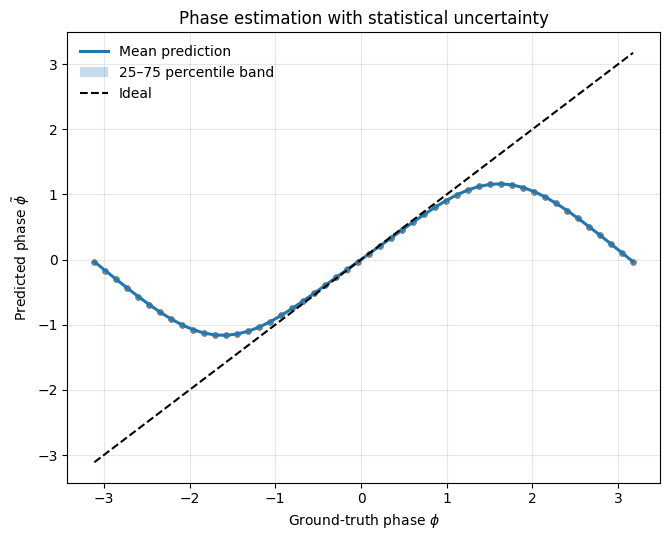

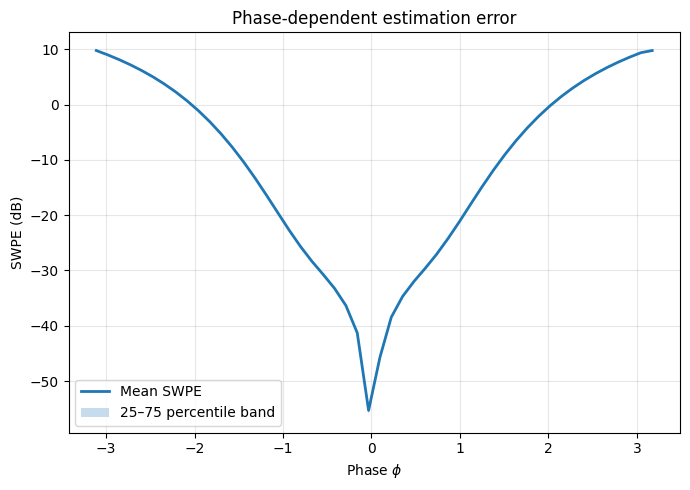

In [9]:
# -----------------------
# === PennyLane device & QNodes ===
# -----------------------
dev_shots = qml.device("default.qubit", wires=n_qubits, shots=10**6)

@qml.qnode(dev_shots, interface=None)
def circuit_probs_shots(phi, q_params):
    """Return computational-basis probabilities for given phi and quantum parameters q_params."""
    # build same circuit but return probs
    # unpack
    t_len = 3 * n_enc
    c_len = 3 * n_dec
    theta_flat = q_params[:t_len] if t_len > 0 else pnp.array([])
    curly_flat = q_params[t_len : t_len + c_len] if c_len > 0 else pnp.array([])

    # input rotation
    for q in range(n_qubits):
        qml.RY(pnp.pi / 2, wires=q)

    # encoding
    for layer_idx in range(n_enc):
        t1 = theta_flat[layer_idx * 3 + 0]
        t2 = theta_flat[layer_idx * 3 + 1]
        t3 = theta_flat[layer_idx * 3 + 2]
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t1 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(t2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for q in range(n_qubits):
            qml.RX(t3, wires=q)

    # phase
    for q in range(n_qubits):
        qml.RZ(phi, wires=q)

    # decoding
    for layer_idx in range(n_dec):
        v1 = curly_flat[layer_idx * 3 + 0]
        v2 = curly_flat[layer_idx * 3 + 1]
        v3 = curly_flat[layer_idx * 3 + 2]
        for q in range(n_qubits):
            qml.RX(v3, wires=q)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v2 / 2.0, i, j)
        for q in range(n_qubits):
            qml.Hadamard(wires=q)
        for i, j in combinations(range(n_qubits), 2):
            rzz_qiskit(v1 / 2.0, i, j)

    for q in range(n_qubits):
        qml.RX(pnp.pi / 2, wires=q)

    return qml.probs(wires=list(range(n_qubits)))

# 2) compute predicted phi for each test phi: phi_pred = sum(a * m * p)
# ensure index_to_m is pnp-compatible array
index_to_m_pnp = pnp.array(index_to_m)

n_runs = 20
phi_preds_all = []  # shape: [runs, phi_points]
mse_phi_list_all = []
for run in range(n_runs):
    phi_preds = []
    mse_phi_list = []
    for phi in phi_trues:
        # probs = circuit_probs_shots(phi, q_params_final)
        # p_m = probs_to_p_m(probs)
        # v = net(p_m)
        # phi_pred = pnp.arctan2(v[0], v[1])
        # phi_preds.append(float(phi_pred))
        probs = circuit_probs_shots(phi, best_x)           # pnp array length 2^n_qubits
        phi_est_m = best_a * index_to_m_pnp   # vector over all basis states
        phi_pred = pnp.sum(phi_est_m * probs)
        mse_phi = pnp.sum((phi - phi_est_m)**2 * probs)
        phi_preds.append(float(phi_pred))       # convert to float for plotting
        mse_phi_list.append(float(mse_phi))

    phi_preds = np.array(phi_preds)
    # phase unwrap correction
    # phi_preds = adjust_phase_wrap(phi_trues, phi_preds)
    phi_preds_all.append(phi_preds)
    mse_phi_list_all.append(np.array(mse_phi_list))


phi_preds_all = np.array(phi_preds_all)  # (runs, N)
np.save(os.path.join(path, "phi_preds_shots20.npy"), phi_preds_all)
mse_phi_list_all = np.array(mse_phi_list_all)  # (runs, N)
np.save(os.path.join(path, "mse_phi_shots20.npy"), mse_phi_list_all)

# =====================================================
# percentile band (NC preferred)
# =====================================================
phi_mean = np.mean(phi_preds_all, axis=0)
phi_lower = np.percentile(
    phi_preds_all,
    25,
    axis=0
)
phi_upper = np.percentile(
    phi_preds_all,
    75,
    axis=0
)

# =====================================================
# Plot: Predicted φ with percentile band
# =====================================================
plt.figure(figsize=(6.8, 5.5))

# main trend
plt.plot(
    phi_trues,
    phi_mean,
    linewidth=2.2,
    label="Mean prediction"
)

# percentile band
plt.fill_between(
    phi_trues,
    phi_lower,
    phi_upper,
    alpha=0.25,
    label="25–75 percentile band"
)

# ideal diagonal
plt.plot(
    phi_trues,
    phi_trues,
    '--',
    color='black',
    linewidth=1.5,
    label="Ideal"
)

# optional: show faint raw points
for run in range(phi_preds_all.shape[0]):
    plt.scatter(
        phi_trues,
        phi_preds_all[run],
        s=12,
        alpha=0.15
    )

plt.xlabel(r"Ground-truth phase $\phi$")
plt.ylabel(r"Predicted phase $\tilde{\phi}$")

plt.title("Phase estimation with statistical uncertainty")

plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(path, "phi_pred_percentile_band.png"),
    dpi=600
)

plt.savefig(
    os.path.join(path, "phi_pred_percentile_band.pdf"),
    bbox_inches='tight',
    dpi=600,
    format='pdf'
)

plt.show()


# =====================================================
# # SWPE with real uncertainty band（NC核心图）
# =====================================================
phase_error = np.angle(np.exp(1j * (phi_preds_all - phi_trues))) ** 2
SWPE_dB_all = 10 * np.log10(phase_error + 1e-12)

SWPE_mean = np.mean(SWPE_dB_all, axis=0)
SWPE_lower = np.percentile(
    SWPE_dB_all,
    25,
    axis=0
)
SWPE_upper = np.percentile(
    SWPE_dB_all,
    75,
    axis=0
)
plt.figure(figsize=(7,5))
plt.plot(
    phi_trues,
    SWPE_mean,
    linewidth=2,
    label="Mean SWPE"
)

plt.fill_between(
    phi_trues,
    SWPE_lower,
    SWPE_upper,
    alpha=0.25,
    label="25–75 percentile band"
)

plt.xlabel(r"Phase $\phi$")
plt.ylabel("SWPE (dB)")
plt.title("Phase-dependent estimation error")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(path, "SWPE_percentile_band.png"),
    dpi=600
)
plt.show()

In [ ]:
import pennylane as qml
import pennylane.numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

# ---------------------------
# 1. 参数设置
# ---------------------------
n_qubits = 8
n_phi = 50
dphi = 1e-5  # 中心差分步长
phi_list = phi_trues 

# ---------------------------
# 3. CFI/QFI 计算函数
# ---------------------------
def compute_CFI_QFI(phi, x, dphi=dphi):
    """中心差分计算纯态下的 CFI 和 QFI"""
    # 计算phi+dphi, phi-dphi的态向量
    psi_plus = circuit_state(phi + dphi, x)
    psi_minus = circuit_state(phi - dphi, x)

    # 中心差分导数
    dpsi = (psi_plus - psi_minus)/(2*dphi)
    psi0 = (psi_plus + psi_minus)/2

    # --- CFI: 使用测量概率分布 ---
    probs = np.abs(psi0)**2
    probs_plus = np.abs(psi_plus)**2
    probs_minus = np.abs(psi_minus)**2
    dp = (probs_plus - probs_minus)/(2*dphi)
    F_c = np.sum((dp**2)/(probs + 1e-12))  # 防止除零

    # --- QFI: 纯态公式 ---
    F_q = 4*(np.vdot(dpsi,dpsi).real - np.abs(np.vdot(psi0,dpsi))**2)

    return float(F_c), float(F_q)

# ---------------------------
# 4. 主循环
# ---------------------------
CFI_list = []
QFI_list = []

for k, phi in enumerate(phi_list):
    if k % 5 == 0:
        print(f"[{k+1}/{len(phi_list)}] Processing phi = {phi:.4f}...")
    fc, fq = compute_CFI_QFI(phi, best_x)
    CFI_list.append(fc)
    QFI_list.append(fq)
    if k % 5 == 0:
        print(f"    -> CFI: {fc:.4f} | QFI: {fq:.4f}")

CFI_arr = np.array(CFI_list)
QFI_arr = np.array(QFI_list)
np.save(os.path.join(path, "CFI_arr.npy"), CFI_arr)
np.save(os.path.join(path, "QFI_arr.npy"), QFI_arr)

# ---------------------------
# 5. 绘图
# ---------------------------
plt.figure(figsize=(10,6))
plt.axhline(n_qubits**2, color='red', linestyle=':', label=f'Heisenberg Limit ({n_qubits**2})', alpha=0.7)
plt.axhline(n_qubits, color='green', linestyle=':', label=f'Standard Quantum Limit ({n_qubits})', alpha=0.7)
plt.plot(phi_list, CFI_arr, label='CFI (Exact)', linewidth=2, color='blue')
plt.plot(phi_list, QFI_arr, '--', label='QFI (Exact)', linewidth=2, color='orange')
plt.xlabel(r'Phase $\phi$')
plt.ylabel('Fisher Information')
plt.title(f'Variational Ramsey CFI vs QFI (N={n_qubits})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.show()


# -----------------------------
# 3. 绘图
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(phi_list, 10*np.log10(mse_phi_list), label=r'Posterior width $\Delta \phi$', linewidth=2, color='blue')
plt.plot(phi_list, 10*np.log10(1/QFI_arr), '--', label=r'Quantum Cramér-Rao bound $1/\sqrt{F_Q}$', linewidth=2, color='orange')
plt.plot(phi_list, 10*np.log10(1/CFI_arr), '--', label=r'Classic Cramér-Rao bound $1/\sqrt{F_C}$', linewidth=2, color='red')

# # 绘制平均值线
plt.axhline(10*np.log10(1/n_qubits), color='blue', linestyle=':', label=f'SQL')
plt.axhline(10*np.log10(1/n_qubits**2), color='orange', linestyle=':', label=f'HL')

plt.xlabel(r'Phase $\phi$', fontsize=14)
plt.ylabel(r'$(\Delta \phi)^2$', fontsize=14)
plt.title(f'$V(\phi)$ vs Quantum fisher info', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [11]:
import numpy as np

eps = 0.01      # 解码分辨率
delta = 0.1    # 相位最小区分尺度

def phase_collision_probability(phi_true, phi_pred, eps=1e-2, delta=0.1):
    """
    phi_true: shape (N,)
    phi_pred: shape (N,)
    eps: prediction resolution threshold
    delta: minimum physical phase separation
    """
    phi_true = np.array(phi_true)
    phi_pred = np.array(phi_pred)
    N = len(phi_true)

    count = 0
    total = 0

    for i in range(N):
        for j in range(i+1, N):
            if np.abs(phi_true[i] - phi_true[j]) > delta:
                total += 1
                if np.abs(phi_pred[i] - phi_pred[j]) < eps:
                    count += 1

    return count / total if total > 0 else 0.0

def decoding_jacobian_stability(phi_true, phi_pred):
    """
    Measures variance of d(phi_pred)/d(phi_true)
    """
    phi_true = np.array(phi_true)
    phi_pred = np.array(phi_pred)

    dphi = phi_true[1] - phi_true[0]
    J = np.gradient(phi_pred, dphi)

    return np.var(J), J

def effective_identifiable_range(phi_true, phi_pred, eta=0.5):
    """
    Fraction of phase domain with stable Jacobian
    """
    phi_true = np.array(phi_true)
    phi_pred = np.array(phi_pred)

    dphi = phi_true[1] - phi_true[0]
    J = np.gradient(phi_pred, dphi)
    J_mean = np.mean(J)

    mask = np.abs(J - J_mean) < eta
    return np.sum(mask) / len(phi_true)

phi_preds = []
for phi in phi_list:
    probs = circuit_probs(phi, best_x)
    phi_est_m = best_a * index_to_m_pnp   # vector over all basis states
    phi_pred = pnp.sum(phi_est_m * probs)
    phi_preds.append(float(qml.math.toarray(phi_pred)))

phi_preds = np.array(phi_preds)

pcp = phase_collision_probability(phi_list, phi_preds)
sigma_J, J = decoding_jacobian_stability(phi_list, phi_preds)
eir = effective_identifiable_range(phi_list, phi_preds)

print("PCP =", pcp)
print("Jacobian variance =", sigma_J)
print("EIR =", eir)


PCP = 0.004897959183673469
Jacobian variance = 0.6437697404738416
EIR = 0.22


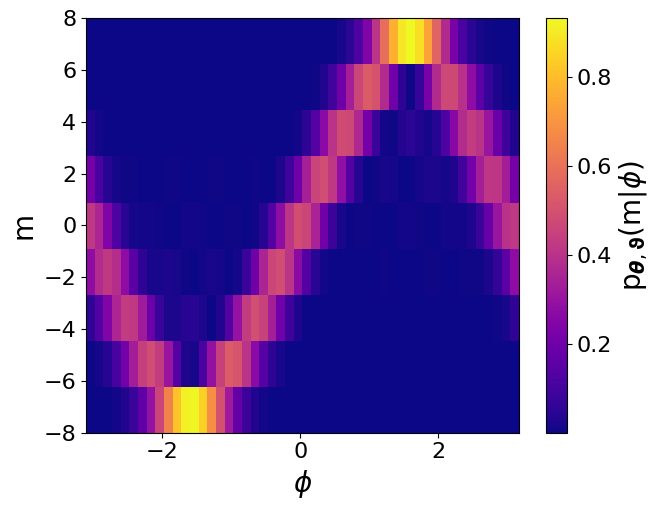

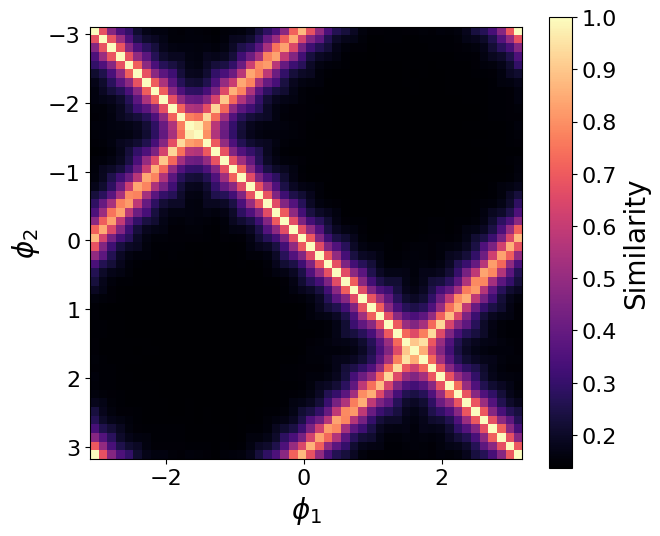

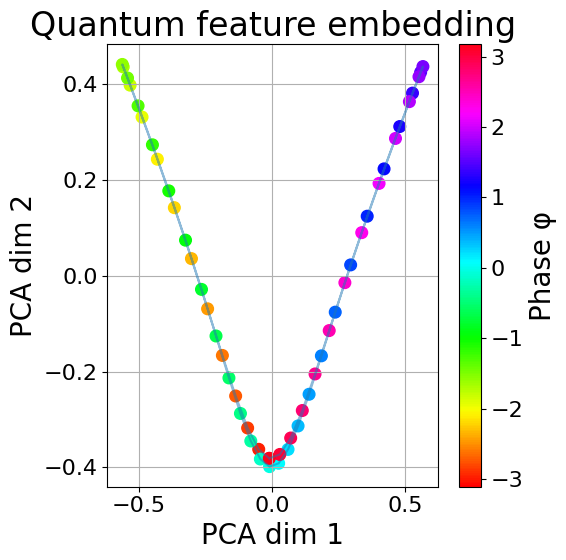

In [16]:
from sklearn.decomposition import PCA

act_func = "vqi"
path = f"VQI/{n_qubits}/vqc_{n_enc}_{n_dec}_{phi_std}/figs"
os.makedirs(path, exist_ok=True)

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 20,          # 全局字体大小
    "axes.labelsize": 20,     # 坐标轴标签
    "xtick.labelsize": 16,    # x轴刻度
    "ytick.labelsize": 16,    # y轴刻度
    "legend.fontsize": 20,
})
# ===============================
# 可视化量子测量特征 p(m|phi)
# ===============================
def probs_to_p_m(probs):
    # probs: vector length 2^n_qubits
    # returns vector of length len(unique_m) where each entry sums probabilities of basis states with same m
    return pnp.array([pnp.sum(probs[index_to_m == m]) for m in unique_m])

    
p_m_matrix = []

for phi in phi_trues:
    probs = circuit_probs(phi, best_x)
    p_m = probs_to_p_m(probs)
    p_m_matrix.append(np.array(p_m))
p_m_matrix = np.array(p_m_matrix)   # shape (n_phi, n_m)

def circuit_probs_batch(phi_array, q_params):
    
    probs_list = []

    for phi in phi_array:
        probs_list.append(circuit_probs(phi, q_params))

    return np.array(probs_list)

# ============================================================
# 1 Quantum Feature Map
# ============================================================
# Compute measurement probability distribution
# p(m | φ)
# ============================================================

def compute_feature_map(phi_trues, q_params):

    probs_batch = circuit_probs_batch(phi_trues, q_params)

    p_m_matrix = np.array([
        probs_to_p_m(p) for p in probs_batch
    ])

    return p_m_matrix

# ============================================================
# 2 Phase Sensitivity
# ============================================================
# Numerical derivative
#
# ∂p(m|φ) / ∂φ
# ============================================================

def compute_sensitivity(phi_trues, q_params):

    dphi = 1e-5

    probs_p = circuit_probs_batch(phi_trues + dphi, q_params)
    probs_m = circuit_probs_batch(phi_trues - dphi, q_params)

    p_plus = np.array([probs_to_p_m(p) for p in probs_p])
    p_minus = np.array([probs_to_p_m(p) for p in probs_m])

    dp_dphi = (p_plus - p_minus) / (2 * dphi)

    return dp_dphi


# ============================================================
# 3 Fisher Information Density
# ============================================================
# Classical Fisher information
#
# I(φ) = Σ ( (∂p/∂φ)^2 / p )
# ============================================================

def compute_fisher_density(p_m_matrix, dp_dphi):

    eps = 1e-12

    I_phi = np.sum(
        (dp_dphi ** 2) / (p_m_matrix + eps),
        axis=1
    )

    return I_phi

# ============================================================
# 4 Phase Identifiability Matrix
# ============================================================
# Measure similarity between phase distributions
#
# S(φ1,φ2) = exp( - ||p(φ1) - p(φ2)|| )
# ============================================================

def compute_phase_identifiability(p_m_matrix):

    n_phi = p_m_matrix.shape[0]

    S = np.zeros((n_phi, n_phi))

    for i in range(n_phi):
        for j in range(n_phi):

            dist = np.sum(np.abs(p_m_matrix[i] - p_m_matrix[j]))

            S[i, j] = np.exp(-dist)

    return S


# ============================================================
# Fig1 Quantum Feature Map
# ============================================================

def plot_feature_map(phi_trues, p_m_matrix, unique_m, path):

    plt.figure(figsize=(7,5.5))

    plt.imshow(
        p_m_matrix.T,
        aspect='auto',
        extent=[phi_trues[0], phi_trues[-1], unique_m[0], unique_m[-1]],
        origin='lower',
        cmap="plasma"
    )

    plt.colorbar(label=r"p$_{\boldsymbol{\theta}, \boldsymbol{\vartheta}}$(m|$\phi$)")
    plt.xlabel(r'$\phi$')
    plt.ylabel("m")
    # plt.title("Quantum feature heatmap")

    plt.tight_layout()

    plt.savefig(f"{path}/Quantum_feature_heatmap.png", dpi=300)


# ============================================================
# Fig2 Quantum Feature Embedding
# ============================================================

def plot_feature_embedding(p_m_matrix, phi_trues, path):

    pca = PCA(n_components=2)

    feature_2d = pca.fit_transform(p_m_matrix)

    plt.figure(figsize=(6,6))

    sc = plt.scatter(
        feature_2d[:,0],
        feature_2d[:,1],
        c=phi_trues,
        cmap="hsv",
        s=70
    )

    plt.plot(feature_2d[:,0], feature_2d[:,1], alpha=0.5)

    plt.colorbar(sc,label="Phase φ")

    plt.xlabel("PCA dim 1")
    plt.ylabel("PCA dim 2")
    plt.title("Quantum feature embedding")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/feature_embedding.png", dpi=300)


# ============================================================
# Fig3 Phase Sensitivity Map
# ============================================================

def plot_sensitivity_map(phi_trues, dp_dphi, unique_m, path):

    plt.figure(figsize=(7,5))

    plt.imshow(
        dp_dphi.T,
        aspect='auto',
        extent=[phi_trues[0], phi_trues[-1], unique_m[0], unique_m[-1]],
        origin='lower',
        cmap="coolwarm"
    )

    plt.colorbar(label="∂p/∂φ")

    plt.xlabel("Phase φ")
    plt.ylabel("Measurement m")

    plt.title("Phase sensitivity")

    plt.tight_layout()

    plt.savefig(f"{path}/phase_sensitivity.png", dpi=300)

# ============================================================
# Fig4  Fisher density
# ============================================================
def plot_fisher_density(p_m_matrix, dp_dphi, phi_trues, path):

    I_phi = compute_fisher_density(p_m_matrix, dp_dphi)
    
    plt.figure(figsize=(7,5))

    plt.plot(phi_trues, I_phi)

    plt.xlabel("Phase φ")
    plt.ylabel("Fisher information")

    plt.title("Fisher information density")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(f"{path}/fisher_density.png", dpi=300)


# ============================================================
# Fig6  Phase Identifiability Map
# ============================================================

def plot_phase_identifiability_map(p_m_matrix, phi_trues, path):

    S = compute_phase_identifiability(p_m_matrix)

    plt.figure(figsize=(7,5.8))

    plt.imshow(
        S,
        extent=[phi_trues[0],phi_trues[-1],phi_trues[-1],phi_trues[0]],
        cmap="magma"
    )

    plt.colorbar(label="Similarity")

    plt.xlabel(r'$\phi_{1}$')
    plt.ylabel(r'$\phi_{2}$')

    # plt.title("Phase identifiability map")

    plt.tight_layout()

    plt.savefig(f"{path}/fig6_phase_identifiability.png", dpi=300)

    plt.show()



# ============================================================
# Fig7  Phase Similarity Curve
# ============================================================

def plot_phase_similarity_curve(phi_trues, p_m_matrix, path):

    phi_idx = len(phi_trues) // 2

    p_ref = p_m_matrix[phi_idx]

    D = np.sum(
        np.abs(p_m_matrix - p_ref),
        axis=1
    )

    plt.figure(figsize=(7,5))

    plt.plot(phi_trues, D)

    plt.xlabel("Phase φ")
    plt.ylabel("Distance to reference")

    plt.title("Phase ambiguity curve")

    plt.grid(True)
    plt.tight_layout()

    plt.savefig(f"{path}/fig7_phase_similarity.png", dpi=300)

    plt.show()

# ============================================================
# Fig8  Linear Estimator Feature
# ============================================================

def plot_linear_feature(p_m_matrix, unique_m, phi_trues, path):

    m_expect = np.sum(p_m_matrix * unique_m, axis=1)

    plt.figure(figsize=(7,5))

    plt.plot(phi_trues, m_expect)

    plt.xlabel("Phase φ")
    plt.ylabel("⟨m⟩")

    plt.title("Linear estimator feature")

    plt.grid(True)

    plt.tight_layout()

    plt.savefig(f"{path}/fig8_linear_feature.png", dpi=300)

    plt.show()

# ============================================================
# Main Analysis
# ============================================================
q_params = best_x

p_m_matrix = compute_feature_map(phi_trues, q_params)

plot_feature_map(phi_trues, p_m_matrix, unique_m, path)

plot_phase_identifiability_map(p_m_matrix, phi_trues, path)

plot_feature_embedding(p_m_matrix, phi_trues, path)


In [15]:
best_x

tensor([ 3.58809973e-01, -4.38641827e-02,  5.88536701e-01,
         5.08765401e-06,  1.68364862e-01,  9.57706065e-02], requires_grad=True)